# Regression - House Pricing

IsaacLun


In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

Download the dataset ***House price prediction*** from Kaggle: https://www.kaggle.com/datasets/shree1992/housedata

#### Loading the dataset

In [57]:
dataset = pd.read_csv('dataset/house-prices/houses.csv')

## Data structure

In [58]:
print(dataset.keys())

Index(['Id', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'BedroomAbvGr', 'TotRmsAbvGrd', 'SalePrice'],
      dtype='object')


In [59]:
print(dataset.head())

   Id  LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  \
0   1         65.0     8450            7            5       2003   
1   2         80.0     9600            6            8       1976   
2   3         68.0    11250            7            5       2001   
3   4         60.0     9550            7            5       1915   
4   5         84.0    14260            8            5       2000   

   BedroomAbvGr  TotRmsAbvGrd  SalePrice  
0             3             8     208500  
1             3             6     181500  
2             3             6     223500  
3             3             7     140000  
4             4             9     250000  


In [60]:
print(dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            1460 non-null   int64  
 1   LotFrontage   1201 non-null   float64
 2   LotArea       1460 non-null   int64  
 3   OverallQual   1460 non-null   int64  
 4   OverallCond   1460 non-null   int64  
 5   YearBuilt     1460 non-null   int64  
 6   BedroomAbvGr  1460 non-null   int64  
 7   TotRmsAbvGrd  1460 non-null   int64  
 8   SalePrice     1460 non-null   int64  
dtypes: float64(1), int64(8)
memory usage: 102.8 KB
None


What do some of the feature vectors look like?

In [61]:
dataset[:5]

,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,BedroomAbvGr,TotRmsAbvGrd,SalePrice
0,1,65.0,8450,7,5,2003,3,8,208500
1,2,80.0,9600,6,8,1976,3,6,181500
2,3,68.0,11250,7,5,2001,3,6,223500
3,4,60.0,9550,7,5,1915,3,7,140000
4,5,84.0,14260,8,5,2000,4,9,250000


In [62]:
print(dataset['BedroomAbvGr'][:5])

0    3
1    3
2    3
3    3
4    4
Name: BedroomAbvGr, dtype: int64


In [63]:
print(dataset['SalePrice'][:5])

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64


In [64]:
features = dataset[['LotFrontage','LotArea','OverallQual','YearBuilt','BedroomAbvGr', 'TotRmsAbvGrd']]
#features = dataset.iloc[:, 1:8]
targets = dataset['SalePrice']

In [65]:
features

,LotFrontage,LotArea,OverallQual,YearBuilt,BedroomAbvGr,TotRmsAbvGrd
0,65.0,8450,7,2003,3,8
1,80.0,9600,6,1976,3,6
2,68.0,11250,7,2001,3,6
3,60.0,9550,7,1915,3,7
4,84.0,14260,8,2000,4,9
...,...,...,...,...,...,...
1455,62.0,7917,6,1999,3,7
1456,85.0,13175,6,1978,3,7
1457,66.0,9042,7,1941,4,9
1458,68.0,9717,5,1950,2,5


In [66]:
targets

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

### Check and clean the data

In [69]:
# Checking missing data
features.isnull().sum()

LotFrontage     259
LotArea           0
OverallQual       0
YearBuilt         0
BedroomAbvGr      0
TotRmsAbvGrd      0
dtype: int64

##### Quick analisys

There are 259 missing values in the 'LotFrontage' feature. We have the option to either drop the rows with missing values, impute or substitute them, or choose not to use this feature in the model.<br>
For now, we will remove this feature from our dataset to avoid issues with missing values and proceed with the remaining features for our analysis.


In [70]:
features = dataset[['LotArea','OverallQual','YearBuilt','BedroomAbvGr', 'TotRmsAbvGrd']]

In [71]:
# Checking missing data
features.isnull().sum()

LotArea         0
OverallQual     0
YearBuilt       0
BedroomAbvGr    0
TotRmsAbvGrd    0
dtype: int64

In [72]:
features[:5]

,LotArea,OverallQual,YearBuilt,BedroomAbvGr,TotRmsAbvGrd
0,8450,7,2003,3,8
1,9600,6,1976,3,6
2,11250,7,2001,3,6
3,9550,7,1915,3,7
4,14260,8,2000,4,9


### Feature scaler (Standardization)
This is a common scaling technique (Standard scaling).

https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

In [73]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

# convert to dataframe
std_features = pd.DataFrame(scaled_features, columns=features.columns)

In [75]:
std_features[:5]

,LotArea,OverallQual,YearBuilt,BedroomAbvGr,TotRmsAbvGrd
0,-0.207142,0.651479,1.050994,0.163779,0.912210
1,-0.091886,-0.071836,0.156734,0.163779,-0.318683
2,0.073480,0.651479,0.984752,0.163779,-0.318683
3,-0.096897,0.651479,-1.863632,0.163779,0.296763
4,0.375148,1.374795,0.951632,1.390023,1.527656


## Split our dataset
We need to split our dataset into *training* and *test* sets. 

We split both the feature vectors (`features`) and the output (`target`).


*  Training set: used for *learning* the model
*   Test set: used for *evaluating* our trained model



In [77]:
# Split the data into training/testing sets (80%/20%)

## Your code
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    std_features, targets, train_size=0.8, random_state=42)

print(f'Training set size: {len(X_train)}')
print(f'Test set size: {len(X_test)}')

Training set size: 1168
Test set size: 292


## Create instance of the model object
Before training, we must create an instance of our linear regression class.

In [38]:
# Create linear regression object
regr = linear_model.LinearRegression()

## Train the model
We train the model on our training set. 

With Scikit-Learn, *training* is done using the `fit(x,y)` function, where `x` is the list of training feature vectors (*input*) and `y` is the corresponding list of target values (*output*). 

All classifier and regressor classes inherit the `fit` function.

In [79]:
# Train the model using the training sets
regr.fit(X_train, y_train)

LinearRegression()

In [80]:
# The coefficients for our line
print('Coefficients: \n', regr.coef_)

Coefficients: 
 [11480.24245383 42186.28839264 13672.52612278 -9051.0024635
 25718.38050453]


## Evaluate the mode (Is it good?)
How good is our model in practice? 

Training gives us a model that minimizes error on the training set. But, if the training set is not representative of the real world, then the model will do poorly in practice.

In [81]:
# Make predictions using the testing set
y_pred = regr.predict(X_test)

In [82]:
print('*Current*')
print(y_test[-5:])
print('\n*Prediction*')
print(y_pred[-5:])

*Current*
479      89471
1361    260000
802     189000
651     108000
722     124500
Name: SalePrice, dtype: int64

*Prediction*
[112661.40955024 235671.86963215 226514.45742872  95457.13453764
  87375.46769885]


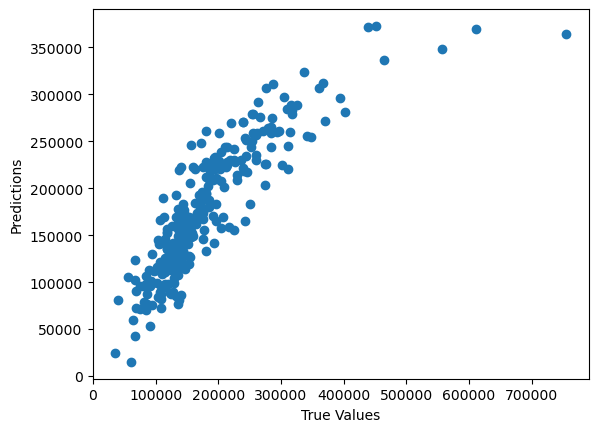

In [85]:
plt.scatter(y_test, y_pred)
plt.xlabel('True Values')
plt.ylabel('Predictions')

plt.show()

892      6900.094887
1105   -36628.387846
413     -4517.628281
522      7054.817958
1036   -26374.883524
            ...     
479     23190.409550
1361   -24328.130368
802     37514.457429
651    -12542.865462
722    -37124.532301
Name: SalePrice, Length: 292, dtype: float64


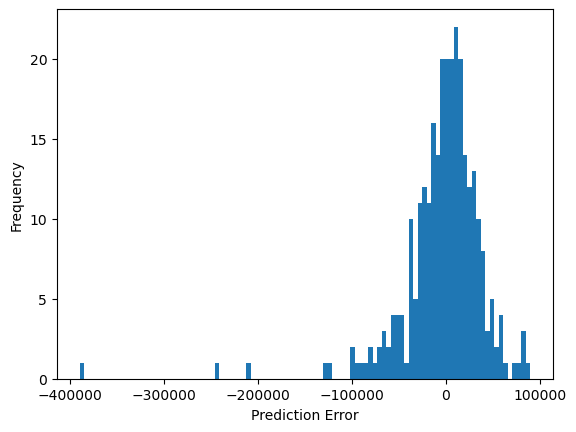

In [86]:
error = y_pred - y_test
print(error)
plt.hist(error, bins=100)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()

In [88]:
# Evaluation metrics

## Measuring Error

We would like to quantify the error. For this, we will use the *Root Mean Square Error* (RMSE).

$$
\text{RMSE} = \sqrt{\frac{1}{m} \sum_{i=1}^{m} (predicted_i - correct_i)^2}
$$

Scikit-Learn has a function for calculating *mean squared error* (MSE). To get RMSE, we just compute the square root of the value returned by this function.

### R² Score

In addition to RMSE, another important metric for evaluating the performance of a regression model is the *R-squared* (\( R^2 \)) score. The \( R^2 \) score indicates how well the regression model explains the variability of the target variable.

The \( R^2 \) score is defined as:

$$
R^2 = 1 - \frac{\sum_{i=1}^{m} (correct_i - predicted_i)^2}{\sum_{i=1}^{m} (correct_i - \bar{correct})^2}
$$


An \( R^2 \) score of 1 indicates a perfect fit, while a score of 0 indicates that the model does not explain any of the variability of the target variable. Negative values of \( R^2 \) can occur when the model performs worse than a simple mean-based model.

Scikit-Learn provides a function to compute the \( R^2 \) score directly, which can be useful to assess the goodness of fit of the model.


## Measuring error

We would like to quantify the error. For this, we will use the *Root Mean Square Error* (RMSE).

$$ error = \sqrt{\frac{1}{m}\sum\limits_{i=1}^{m}{(predicted_i - correct_i)^2}} $$


Scikit-Learn has a function for calculating *mean squared error* (MSE). To get RMSE, we just compute the square root of the value returned by this function.



In [89]:
# The root mean squared error (RMSE)
print("Root mean squared error: %.2f"
      % np.sqrt(mean_squared_error(y_test, y_pred)))

# 266097.21

Root mean squared error: 45025.19


In [90]:
print("R^2 score: %.2f" % r2_score(y_test, y_pred))

R^2 score: 0.74
